## Building the main GPT model and Attention(Self + Multi) here:
---

### Imports :
---

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F



In [2]:
# hyperparameters

## use the batch_size = 32/16 for escaping the cuda out of memory 
batch_size = 32 # how many independent sequences will we process in parallel? 
block_size = 256 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.2

torch.manual_seed(1337)
# ------------
print(device)
print(torch.cuda.get_device_name(0) if device == 'cuda' else 'cpu' )

cuda
NVIDIA GeForce RTX 2050


### Dataset : Tiny shakespear 

In [4]:
with open('input_tiny_shakespear.txt','r',encoding='utf-8') as f:
    text = f.read()



### data pre-processing 
- like conversion of str -> int or (vise versa)
- length of vocabulary
- no of unique chars 
----

In [6]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

## Train and test splits
---

In [7]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]


## Data loading in batches and eval function:
--- 

In [8]:
# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

##  Self Attention & Multi Attention blocks of transformer :
---

### 1. Self Attention block:
---

In [9]:
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # input of size (batch, time-step, channels)
        # output of size (batch, time-step, head size)
        B,T,C = x.shape
        k = self.key(x)   # (B,T,hs)
        q = self.query(x) # (B,T,hs)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 # (B, T, hs) @ (B, hs, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,hs)
        out = wei @ v # (B, T, T) @ (B, T, hs) -> (B, T, hs)
        return out

### Multi Head Attention & Feed Forward :
----

In [10]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

### Transformer block for the model :
---

In [11]:
class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

## GPT Model class :
---

In [12]:
class GPTLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

        # better init, not covered in the original GPT video, but important, will cover in followup video
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

### Defining the model :
---

In [13]:
model = GPTLanguageModel()
m = model.to(device)

## Parameters of the model:
---

In [14]:
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')


10.788929 M parameters


### Creating the optumizer:
---

In [15]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)


In [16]:
train_losses = []
val_losses = []
steps = []

## Traning and loss prediction & Evaluation :
---

In [17]:
for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_loss = losses['train'].item()
        val_loss = losses['val'].item()
        steps.append(iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"step {iter:.4f}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0.0000: train loss 4.2216, val loss 4.2311
step 500.0000: train loss 1.9706, val loss 2.0814
step 1000.0000: train loss 1.5250, val loss 1.7213
step 1500.0000: train loss 1.3804, val loss 1.6046
step 2000.0000: train loss 1.3001, val loss 1.5449
step 2500.0000: train loss 1.2412, val loss 1.5227
step 3000.0000: train loss 1.1962, val loss 1.4984
step 3500.0000: train loss 1.1542, val loss 1.4945
step 4000.0000: train loss 1.1225, val loss 1.4940
step 4500.0000: train loss 1.0880, val loss 1.4799
step 4999.0000: train loss 1.0513, val loss 1.4986


## Testing & generate from the model:
---

In [ ]:
## user prompt (for just test case for me :) 
usr_prompt = 'hello world here'

no_wds = usr_prompt.split()

prompt_len = len(no_wds)

## encode it 
encode_prompt = encode(usr_prompt)

##convert into 2D tensor to give it to the transformer model 

input_context = torch.tensor([encode_prompt],dtype=torch.long,device= device)

print(prompt_len)

3


In [18]:

context = torch.zeros((1, 1), dtype=torch.long, device=device)

print(decode(m.generate(context, max_new_tokens=100)[0].tolist()))



First With Servingman:
One done thou after a tearful womans,
and for Distinius, or with the rey.

M


## Plotting the train v/s losss graph :
----

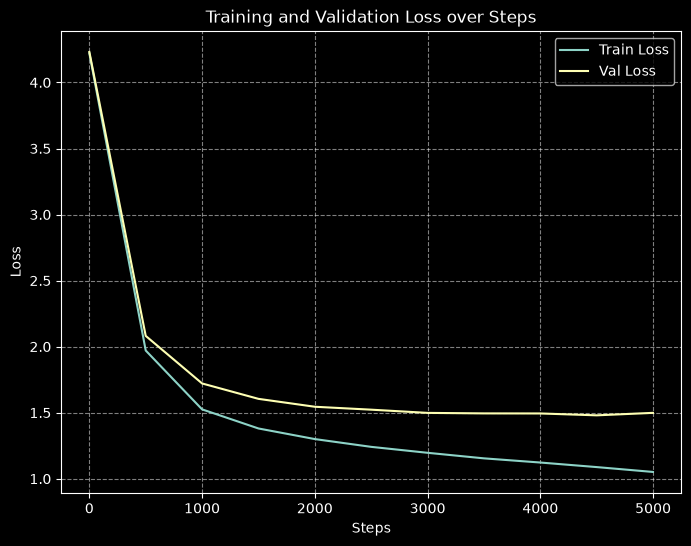

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(steps, train_losses, label='Train Loss')
plt.plot(steps, val_losses, label='Val Loss')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True,linestyle='--', alpha=0.5)
plt.show()


## saving the model:
---

In [ ]:
import os

# from torch.utils import checkpoint 

os.makedirs("checkpoints",exist_ok=True)

checkpoint = {
    'model_state_dict':model.state_dict(),
    'model_config':{
        "block_size":block_size,
        "n_embd":n_embd,
        "n_head":n_head,
        "n_layer":n_layer,
        "dropout":dropout,
        "vocab_size":vocab_size,
    },
    "chars":chars,
    "stoi":stoi,
    "itos":itos,
}

torch.save(checkpoint,"checkpoints/nano_gpt_model.pth")
print("Model saved")

Model saved
